# NB04 — Capacity ladder and the Oracle

`C0` is the paper's own patching configuration, which builds no projector on either side. 
And `C128` is the rank its projectors are actually capped at, because `model/utils.py:252–253` makes every trainable projector a LoRA target module. Indeed, `C128` is also what `Cfull` degrades to if the input map is ever routed through LoRA.
The rest of the arms are ours and their purpose is to distinguish between "the self-explainer advantage collapses under rotation" and "the paper's setup cannot represent `Q^{-1}`. 


We test different capacities to see if the explainer can represent `Q^{-1}`, which will hopefully rule out the possibility that collapse under rotation is due to parameter count and not activation alignment.

| Arm | Input map on `v` | Represents `Q^{-1}`? | Trainable |
|---|---|---|---|
| `C0` | none | No | — |
| `C8` / `C128` / `C512` | rank 8 / 128 / 512 | No / No / partially | yes |
| `Cfull` | full-rank `d×d`, init `I` | exactly | yes |
| `Oracle` | frozen at `Q^T` | exactly | **no** |

`Oracle` serves two purposes. 
First, the difference `Oracle − Cfull/R-Q` measures the ability for the model to learn the inverse map.
Second, `Oracle` under `R-Q` is algebraically identical to `C0` under R-id, so they should yield almost identical results.


In [1]:
# --- dependencies -----------------------------------------------------------
# A RunPod image ships torch built against the pod's own driver, so nothing here may
# replace it: se_env pins the installed torch as a pip constraint and installs only what
# is missing or below the floor these notebooks need — including bitsandbytes, which Colab
# had preinstalled and RunPod images do not (se_common asks for paged_adamw_8bit).
# Safe to re-run: a no-op on a warm pod.
import os
import sys

# `se/` holds the shared modules: se_env, se_config, rotate, se_common. Clone this repo
# onto the pod's volume (/workspace/self_explainer) so it survives the pod.
REPO_DIR = os.environ.get("SE_REPO_DIR", "/workspace/self_explainer")
if not os.path.isdir(os.path.join(REPO_DIR, "se")):
    REPO_DIR = os.path.abspath(".." if os.path.isdir("../se") else ".")
sys.path.insert(0, os.path.join(REPO_DIR, "se"))

import se_env

se_env.ensure_deps()


dependencies: already satisfied (torch 2.8.0+cu128, transformers 5.15.0, peft 0.20.0, trl 1.10.0, bitsandbytes 0.50.1)


{}

In [2]:
# --- environment ------------------------------------------------------------
# Caches and outputs go on the pod's volume, never the container disk: /workspace is what
# survives a stopped or terminated pod, and the 8B checkpoint alone is 16 GB. HF_TOKEN comes
# from the pod template's environment or <volume>/.hf_token — there is no prompt to answer,
# because a preempted pod restarts with nobody watching.
#
# Same training path as NB03, walked up the capacity ladder.
env = se_env.bootstrap(repo_dir=REPO_DIR, gpu="required", min_vram_gb=80)

import se_config as C


RUNPOD ENVIRONMENT
host    : RunPod pod 6uqtvsxboal2o6  |  python 3.12.3
gpu     : 1 x NVIDIA A100 80GB PCIe  |  79 GiB  |  bf16 yes
torch   : 2.8.0+cu128  (CUDA 12.8)
stack   : transformers 5.15.0 · peft 0.20.0 · trl 1.10.0 · datasets 5.0.1 · accelerate 1.14.0 · bitsandbytes 0.50.1
repo    : /workspace/self_explainer
volume  : /workspace  (own mount, 480358 GiB free)
hf cache: /workspace/.cache/huggingface/
outputs : /workspace/self_explainer
hf token: none
!! no HF token found. Public checkpoints still work; set HF_TOKEN in the pod template or write it to /workspace/.hf_token if a download 401s.


In [3]:
import json
import subprocess
import time

import pandas as pd
import torch

import rotate as R
import se_common as S

# cheap check that the ladder is a real capacity ladder before spending GPU hours on it
print(subprocess.run([sys.executable, f"{REPO_DIR}/se/test_input_map.py"],
                     capture_output=True, text=True).stdout)



arms start at their base map
  [ok ] rank=0 starts at identity — max |delta| = 0.0e+00
  [ok ] rank=4 starts at identity — max |delta| = 0.0e+00
  [ok ] rank=8 starts at identity — max |delta| = 0.0e+00
  [ok ] rank='full' starts at identity — max |delta| = 0.0e+00
  [ok ] rank=0 starts at the ridge map — max |delta| = 4.1e-08
  [ok ] rank=4 starts at the ridge map — max |delta| = 4.1e-08
  [ok ] rank='full' starts at the ridge map — max |delta| = 4.1e-08

rank is a real capacity constraint (fitting Pi -> Q^T, d=32)
      rank=   0  relative residual = 1.9971
      rank=   2  relative residual = 1.7549
      rank=   8  relative residual = 1.0563
      rank=  16  relative residual = 0.3485
      rank=full  relative residual = 0.0000
  [ok ] C0 cannot invert the rotation at all — residual = 1.997
  [ok ] Cfull inverts it essentially exactly — residual = 6.69e-19
  [ok ] residual decreases monotonically with rank
  [ok ] rank-2 arm attains its truncation bound — got 1.755, best possible 

## 0. Check full-rank trainability first

The paper's code `model/utils.py:252–253` appends every trainable projector to LoRA's `target_modules`; under `lora_r: 128`.
A "full rank" projector is then frozen-at-init plus a rank 128-update, which cannot approximate `Q^T` which is rank 4096.
If `Cfull` ends up in `target_modules` the central arm all become `C128` and the experiment measures LoRA rank not basis.

`se_common.run_training` asserts the input-map parameter count on every run and records it in `metrics.json`.


In [4]:
from transformers import AutoConfig

cfg = AutoConfig.from_pretrained(C.TARGET_MODEL_ID)
d = cfg.hidden_size

rows = []
for cap in C.CAPACITIES:
    n_params = S.expected_input_map_params(cap, d, d)
    rows.append({"arm": cap, "rank": C.CAPACITY_RANK[cap],
                 "trainable_params": n_params,
                 "params_M": round(n_params / 1e6, 2),
                 "pct_of_Cfull": round(100 * n_params
                                       / S.expected_input_map_params("Cfull", d, d), 2),
                 "status": C.CAPACITY_STATUS[cap]})
ladder_budget = pd.DataFrame(rows)
print(ladder_budget.to_string(index=False))

cfull = S.expected_input_map_params("Cfull", d, d)
c128 = S.expected_input_map_params("C128", d, d)

checks = [
    ("input map is outside LoRA target_modules",
     "input_map" not in C.LORA_TARGET_MODULES),
    (f"Cfull trains {C.N_LAYER_CHUNKS} x {d}^2 = {cfull:,} parameters",
     cfull == C.N_LAYER_CHUNKS * d * d),
    (f"C128 is a real cap: {c128:,} is {100 * c128 / cfull:.1f}% of Cfull",
     c128 < cfull / 10),
    ("the runtime assertion exists and is wired into run_training",
     hasattr(S, "check_input_map_trainability")),
]
print()
for name, ok in checks:
    print(f"  [{'ok  ' if ok else 'FAIL'}] {name}")
    assert ok, name

print(f"\nThe paper's projectors are per LAYER, so §3.1 quotes {32 * d * d / 1e6:.0f}M for 32 of "
      f"them.\nOurs are per layer CHUNK (N_LAYER_CHUNKS = {C.N_LAYER_CHUNKS}), so the same "
      f"argument lands at {cfull / 1e6:.0f}M.\nThe shape of the check is what matters: a few "
      f"million where tens of millions belong means a rank cap.")


       arm rank  trainable_params  params_M  pct_of_Cfull                                    status
        C0    0                 0      0.00          0.00 the paper's configuration (no map at all)
        C8    8            262144      0.26          0.39                           ladder interior
      C128  128           4194304      4.19          6.25 the paper's rank cap on a projector (F.3)
      C512  512          16777216     16.78         25.00                           ladder interior
     Cfull full          67108864     67.11        100.00                     primary augmented arm
Cfull-rand full          67108864     67.11        100.00                              init control
    Oracle    0                 0      0.00          0.00                  representability ceiling

  [ok  ] input map is outside LoRA target_modules
  [ok  ] Cfull trains 4 x 4096^2 = 67,108,864 parameters
  [ok  ] C128 is a real cap: 4,194,304 is 6.2% of Cfull
  [ok  ] the runtime assertion exist

## 1. The exactness check: `Oracle`/R-Q ≡ `C0`/R-id

`Oracle` is frozen at `Q^T` and receives `Qv` while `C0` has no map and receives `v`.
Both hand the model exactly `v`. The identity is algebraic and holds exactly in real arithmetic,
so it is the one place in this project where a wiring fault has nowhere to hide.

It is checked at two levels, because they falsify different things.

**§1a, on the data.** `Q^T (Qv) = v` on the stored vectors, in float64, with no model involved.
This is deterministic: it either holds or it does not, and it is what actually catches row
misalignment, a stale `Q`, or a transposed orientation. It costs seconds and runs before any GPU
time is spent.

**§1b, end to end.** Two training runs. These are the same computation only up to floating point:
the vectors reach the map in float32 and leave it quantized to the explainer's dtype, so the two
arms' injected embeddings differ in the last bits, the gradients differ, and the two LoRAs land in
different places. The runs are therefore two draws from the same process, not one computation
performed twice, and the tolerance has to be the width of that process — the preregistered
`exactness_tol`, on the preregistered primary metric, stated as a paired difference over the shared
eval set. The secondary metrics are printed as diagnostics and do not gate: `has_changed_f1` is a
macro-F1 over a three-valued prediction (changed / unchanged / unparseable) and moves several times
more than a proportion does for the same underlying disagreement.


In [5]:
# --- 1a. the algebraic check, on the data, before any GPU time -----------------
# Q^T (Qv) = v is exact in real arithmetic. If this fails, no training run can rescue it and
# nothing downstream means anything -- so it runs first and it is a hard assert.
tokenizer = S.load_tokenizer()
Q, q_seed = R.load_rotation(f"{C.ROTATION_DIR}/Q_seed{C.Q_SEED}.pt")
datasets = {arm: S.load_ready_dataset(arm) for arm in ("identity", "Q")}

algebra = S.check_rotation_exactness(datasets["Q"], datasets["identity"], Q)
print(f"§1a ALGEBRAIC CHECK — Q (seed {q_seed}), {algebra['n_checked']} rows, float64")
print("=" * 60)
print(f"  max ||Qv_id - v_rot|| / ||v_id||   : {algebra['max_rel_residual']:.2e}")
print(f"  max ||Q^T v_rot - v_id|| / ||v_id||: {algebra['max_rel_round_trip']:.2e}   "
      f"(round trip at {S.MAP_DTYPE})")
print(f"  max |Q Q^T - I|                    : {algebra['max_orthogonality_error']:.2e}")
print(f"  chunk_ids aligned row for row      : {algebra['chunk_ids_aligned']}")

if not algebra["passed"]:
    print("\nFAIL — the rotated dataset on disk is not Q times the identity dataset.")
    print("Suspects, in the order they are worth checking:")
    print("  1. the dataset was built by a different Q than the one loaded here — rerun NB02")
    print("     after any change to Q_SEED or NB01")
    print("  2. row misalignment: the two arms came from different shuffles of the base set")
    print("  3. orientation: M applied as M^T (self-consistent everywhere except here)")
assert algebra["passed"], "rotated dataset is not Q * identity dataset"
print("\nPASS — the data is exact. Any difference below is training, not wiring.")


§1a ALGEBRAIC CHECK — Q (seed 20260816), 256 rows, float64
  max ||Qv_id - v_rot|| / ||v_id||   : 2.63e-08
  max ||Q^T v_rot - v_id|| / ||v_id||: 2.69e-08   (round trip at torch.float32)
  max |Q Q^T - I|                    : 6.66e-15
  chunk_ids aligned row for row      : True

PASS — the data is exact. Any difference below is training, not wiring.


In [6]:
# --- 1b, part one: the two runs. tokenizer, Q and datasets come from 1a above
N_CHECK = min(C.N_TRAIN_LADDER)
oracle_mats = S.oracle_matrices(Q)

print(f"=== Oracle · R-Q · n={N_CHECK} " + "=" * 30)
kw_o = dict(tokenizer=tokenizer, dataset=datasets["Q"], ridge_matrices=oracle_mats)
S.run_training(N_CHECK, "Q", "Oracle", "oracle", **kw_o)
oracle_scores = S.eval_run(N_CHECK, "Q", "Oracle", "oracle", **kw_o)

print(f"\n=== C0 · R-id · n={N_CHECK} " + "=" * 30)
kw_c = dict(tokenizer=tokenizer, dataset=datasets["identity"])
S.run_training(N_CHECK, "identity", "C0", "identity", **kw_c)
c0_scores = S.eval_run(N_CHECK, "identity", "C0", "identity", **kw_c)


=== Oracle · R-Q · n=512 ==============================
[skip] /workspace/self_explainer/runs/patching/expl_Qwen3-8B/rot_Q/cap_Oracle/init_oracle/n_train_512 already done

=== C0 · R-id · n=512 ==============================
[skip] /workspace/self_explainer/runs/patching/expl_Qwen3-8B/rot_identity/cap_C0/init_identity/n_train_512 already done


In [7]:
# --- 1b. the same identity, end to end ----------------------------------------
prereg = json.load(open(f"{C.REPORTS_DIR}/preregistration.json"))
PRIMARY = prereg["primary_metric"]
TOL = prereg["thresholds"]["exactness_tol"]

# paired over the shared eval set: McNemar's se = sqrt(b + c) / n, several times tighter than
# sqrt(2) x the per-arm binomial half-width, which at n=1024 is +/-0.043 on its own
rec_o = S.load_eval_records(N_CHECK, "Q", "Oracle", "oracle")
rec_c = S.load_eval_records(N_CHECK, "identity", "C0", "identity")
pair = S.paired_delta(rec_o, rec_c, key=PRIMARY) if (rec_o and rec_c) else None

print("§1b END-TO-END CHECK — Oracle/R-Q vs C0/R-id")
print("=" * 60)
for m in ["exact_match", "has_changed_f1", "content_match", "unparseable_rate"]:
    if m not in oracle_scores:
        continue
    dist = oracle_scores[m] - c0_scores[m]
    gate = "  <- gated" if m == PRIMARY else "  (diagnostic)"
    print(f"  {m:>17}: Oracle {oracle_scores[m]:.4f}  C0 {c0_scores[m]:.4f}  "
          f"delta {dist:+.4f}{gate}")

if pair:
    print(f"\n  paired {PRIMARY}: delta {pair['delta']:+.4f} "
          f"+/- {1.96 * pair['se']:.4f} (95%), discordant {pair['discordant_a']}/"
          f"{pair['discordant_b']} of {pair['n']}")
    print(f"  the two runs disagree on {pair['discordant_a'] + pair['discordant_b']} of "
          f"{pair['n']} items, which is the size of the floating-point divergence")

delta_primary = oracle_scores[PRIMARY] - c0_scores[PRIMARY]
passed = abs(delta_primary) <= TOL

result = {"oracle": oracle_scores, "c0": c0_scores,
          "deltas": {m: oracle_scores[m] - c0_scores[m]
                     for m in ("exact_match", "has_changed_f1", "content_match")},
          "primary_metric": PRIMARY, "primary_delta": delta_primary,
          "paired": pair, "algebraic": algebra, "tolerance": TOL, "passed": passed}
with open(f"{C.REPORTS_DIR}/exactness_check.json", "w") as f:
    json.dump(result, f, indent=2)

if passed:
    print(f"\nPASS — {PRIMARY} agrees within the preregistered {TOL}, on top of an exact §1a.")
    print("The injection path is wired correctly.")
else:
    print(f"\nFAIL — {PRIMARY} differs by {delta_primary:+.4f}, past the preregistered {TOL},")
    print("and §1a already ruled out the data. That leaves the injection path itself:")
    print("  1. is the map running at MAP_DTYPE, or is v being quantized before it? A cast on")
    print("     the near side of Pi makes Oracle compute Q^T bf16(Qv), which differs from")
    print("     C0's bf16(v) in ~82% of coordinates -- more than bf16 quantization itself")
    print("  2. did the two runs share seed, data order, and n_train (metrics.json records all")
    print("     three)?")
    print("  3. does Oracle's frozen base survive the PEFT save/load round trip into eval?")
assert passed, f"exactness check failed on {PRIMARY}"


§1b END-TO-END CHECK — Oracle/R-Q vs C0/R-id
        exact_match: Oracle 0.3828  C0 0.3867  delta -0.0039  <- gated
     has_changed_f1: Oracle 0.5295  C0 0.5237  delta +0.0058  (diagnostic)
      content_match: Oracle 0.5811  C0 0.5762  delta +0.0049  (diagnostic)
   unparseable_rate: Oracle 0.0000  C0 0.0000  delta +0.0000  (diagnostic)

  paired exact_match: delta -0.0039 +/- 0.0158 (95%), discordant 32/36 of 1024
  the two runs disagree on 68 of 1024 items, which is the size of the floating-point divergence

PASS — exact_match agrees within the preregistered 0.02, on top of an exact §1a.
The injection path is wired correctly.


## 2. What each rung costs

The parameter count for each rung on the ladder and how it compares to LoRA budget for each.
Shows that `Cfull` is ~4× a single matrix and exceeds the LoRA parameter count rather
than being negligible.


In [8]:
# cfg and d come from §0 above, which loaded them for the trap-box assertion
head_dim = getattr(cfg, "head_dim", d // cfg.num_attention_heads)
shapes = {"q_proj": (d, cfg.num_attention_heads * head_dim),
          "k_proj": (d, cfg.num_key_value_heads * head_dim),
          "v_proj": (d, cfg.num_key_value_heads * head_dim),
          "o_proj": (cfg.num_attention_heads * head_dim, d),
          "gate_proj": (d, cfg.intermediate_size), "up_proj": (d, cfg.intermediate_size),
          "down_proj": (cfg.intermediate_size, d)}
lora_params = cfg.num_hidden_layers * sum(
    C.LORA_R * (i + o) for k, (i, o) in shapes.items() if k in C.LORA_TARGET_MODULES)

rows = []
for cap in C.CAPACITIES:
    total = S.expected_input_map_params(cap, d, d)
    rows.append({"arm": cap, "rank": C.CAPACITY_RANK[cap],
                 "trainable": cap != "Oracle",
                 "map_params_M": total / 1e6,
                 "pct_of_lora": 100 * total / lora_params,
                 "status": C.CAPACITY_STATUS[cap]})
print(f"LoRA budget: {lora_params/1e6:.1f}M trainable params")
print(f"The paper's own LoRA rank is {C.PAPER_LORA_R}; ours is {C.LORA_R}, inherited from the")
print("base replication. The rank that matters for the ladder is the one on the input map.")
pd.DataFrame(rows).round(2)


LoRA budget: 43.6M trainable params
The paper's own LoRA rank is 128; ours is 16, inherited from the
base replication. The rank that matters for the ladder is the one on the input map.


,arm,rank,trainable,map_params_M,pct_of_lora,status
0,C0,0,True,0.00,0.00,the paper's configuration (no map at all)
1,C8,8,True,0.26,0.60,ladder interior
2,C128,128,True,4.19,9.61,the paper's rank cap on a projector (F.3)
3,C512,512,True,16.78,38.44,ladder interior
4,Cfull,full,True,67.11,153.75,primary augmented arm
5,Cfull-rand,full,True,67.11,153.75,init control
6,Oracle,0,False,0.00,0.00,representability ceiling


## 3. Run the ladder

Rotated activations at three `N`. 
The identity arm is only run at `C0` and `Cfull` because the intermediate rungs are uninformative under R-id since no inversion is needed.
We are interested in capacity needed to invert the rotation.

The rungs are `C0`, `C8`, `C128`, `C512`, `Cfull` (`C128` to match the paper).


In [9]:
LADDER = ["C0", "C8", "C128", "C512", "Cfull"]

jobs = [("Q", cap, C.CAPACITY_DEFAULT_INIT[cap], None) for cap in LADDER]
jobs += [("Q", "Oracle", "oracle", oracle_mats)]
jobs += [("identity", cap, C.CAPACITY_DEFAULT_INIT[cap], None) for cap in ("C0", "Cfull")]

# 3 seeds per N, matching NB03: N_TRAIN_LADDER is entirely inside MULTI_SEED_N, and the
# prereg cost accounting for the seed-band expansion assumed the ladder already paid this
# (prereg_threshold_justification.md: "NB04 ... unaffected: their arms run at
# N_TRAIN_LADDER, which already had three seeds"). Cut rungs before cutting seeds -- see
# the cell above.
ladder_results = []
for n in C.N_TRAIN_LADDER:
    for seed in C.seeds_for(n):
        for rot, cap, init, mats in jobs:
            t0 = time.time()
            print(f"\n=== {C.ROTATION_LABEL[rot]} · {cap} · n={n} · seed={seed} " + "=" * 16)
            kw = dict(tokenizer=tokenizer, dataset=datasets[rot], ridge_matrices=mats, seed=seed)
            S.run_training(n, rot, cap, init, **kw)
            scores = S.eval_run(n, rot, cap, init, **kw)
            ladder_results.append(scores)
            print(f"  exact_match {scores['exact_match']:.3f} "
                  f"| content_match {scores['content_match']:.3f} [{(time.time()-t0)/60:.1f} min]")

ladder = pd.DataFrame(ladder_results)
ladder.to_csv(f"{C.REPORTS_DIR}/capacity_ladder.csv", index=False)

# §7.5's first item, verified from what the runs actually recorded rather than from intent
audits = []
for rot, cap, init, _ in jobs:
    for n in C.N_TRAIN_LADDER:
        for seed in C.seeds_for(n):
            path = f"{C.run_dir('patching', rot, cap, init, n, seed=seed)}/metrics.json"
            if not os.path.exists(path):
                continue
            m = json.load(open(path))
            audits.append({"rotation": rot, "capacity": cap, "n_train": n, "seed": seed,
                           "trainable": m.get("input_map_trainable_params"),
                           "expected": m.get("input_map_expected_params"),
                           "lora_wrapped": bool(m.get("input_map_lora_wrapped")),
                           "ok": m.get("full_rank_ok")})
if audits:
    ad = pd.DataFrame(audits)
    print("\ninput-map audit, per run (§7.5):")
    print(ad.to_string(index=False))
    assert ad.ok.fillna(False).all(), (
        "a run's input map was rank-capped or LoRA-wrapped -- the arm is not what it says "
        "it is (Appendix F.3). Stop and fix target_modules.")

ladder[["rotation", "capacity", "n_train", "seed", "exact_match", "content_match"]]


=== R-Q · C0 · n=512 · seed=67 ================
[skip] /workspace/self_explainer/runs/patching/expl_Qwen3-8B/rot_Q/cap_C0/init_identity/n_train_512 already done
  exact_match 0.392 | content_match 0.592 [0.0 min]

=== R-Q · C8 · n=512 · seed=67 ================
[skip] /workspace/self_explainer/runs/patching/expl_Qwen3-8B/rot_Q/cap_C8/init_identity/n_train_512 already done
  exact_match 0.406 | content_match 0.590 [0.0 min]

=== R-Q · C128 · n=512 · seed=67 ================
[skip] /workspace/self_explainer/runs/patching/expl_Qwen3-8B/rot_Q/cap_C128/init_identity/n_train_512 already done
  exact_match 0.424 | content_match 0.611 [0.0 min]

=== R-Q · C512 · n=512 · seed=67 ================
[skip] /workspace/self_explainer/runs/patching/expl_Qwen3-8B/rot_Q/cap_C512/init_identity/n_train_512 already done
  exact_match 0.420 | content_match 0.604 [0.0 min]

=== R-Q · Cfull · n=512 · seed=67 ================
[skip] /workspace/self_explainer/runs/patching/expl_Qwen3-8B/rot_Q/cap_Cfull/init_id

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

  input map: 4,194,304 trainable (expected 4,194,304), 4,194,304 frozen (PEFT's modules_to_save keeps the original alongside its trainable copy), LoRA-wrapped: no


Epoch,Training Loss,Validation Loss
1,0.569894,0.122333
2,0.326179,0.112691
3,0.209422,0.122071


Training Loss,Validation Loss,Epoch
0.209422,0.122071,3


...

Training Loss,Validation Loss,Epoch
0.128264,0.086443,3


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:452: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

  exact_match 0.701 | content_match 0.764 [125.3 min]

=== R-id · C0 · n=16384 · seed=67 ================
[skip] /workspace/self_explainer/runs/patching/expl_Qwen3-8B/rot_identity/cap_C0/init_identity/n_train_16384 already done
  exact_match 0.701 | content_match 0.754 [0.0 min]

=== R-id · Cfull · n=16384 · seed=67 ================
[skip] /workspace/self_explainer/runs/patching/expl_Qwen3-8B/rot_identity/cap_Cfull/init_identity/n_train_16384 already done
  exact_match 0.708 | content_match 0.765 [0.0 min]

input-map audit, per run (§7.5):
rotation capacity  n_train  seed  trainable  expected  lora_wrapped   ok
       Q       C0      512    67          0         0         False True
       Q       C0      512    68          0         0         False True
       Q       C0      512    69          0         0         False True
       Q       C0     2048    67          0         0         False True
       Q       C0     2048    68          0         0         False True
       Q       C

,rotation,capacity,n_train,seed,exact_match,content_match
0,Q,C0,512,67,0.391602,0.591797
1,Q,C8,512,67,0.406250,0.589844
2,Q,C128,512,67,0.423828,0.611328
3,Q,C512,512,67,0.419922,0.603516
4,Q,Cfull,512,67,0.459961,0.625000
5,Q,Oracle,512,67,0.382812,0.581055
6,identity,C0,512,67,0.386719,0.576172
7,identity,Cfull,512,67,0.415039,0.599609
8,Q,C0,512,68,0.405273,0.597656
9,Q,C8,512,68,0.416992,0.598633


## 4. The recovery plot

There are three references:
-  `Cfull`/R-id, what the unrotated explainer achieves 
- `Oracle`, what a perfect inverse achieves without having to learn it, 
- no-activation floor from NB03 1

The difference of the rotated ladder and `Oracle` is the learnability of the rotation.
`Oracle` and `Cfull`/R-id is the cost of rotation that inverting the frame doesn't fix (if rotating activations were purely relabing coordinates then the difference would be zero). This isolates the cost of rotation itself, independent of the rest of the pipeline.
The distance from the floor is how much better than no activation information the each performs.

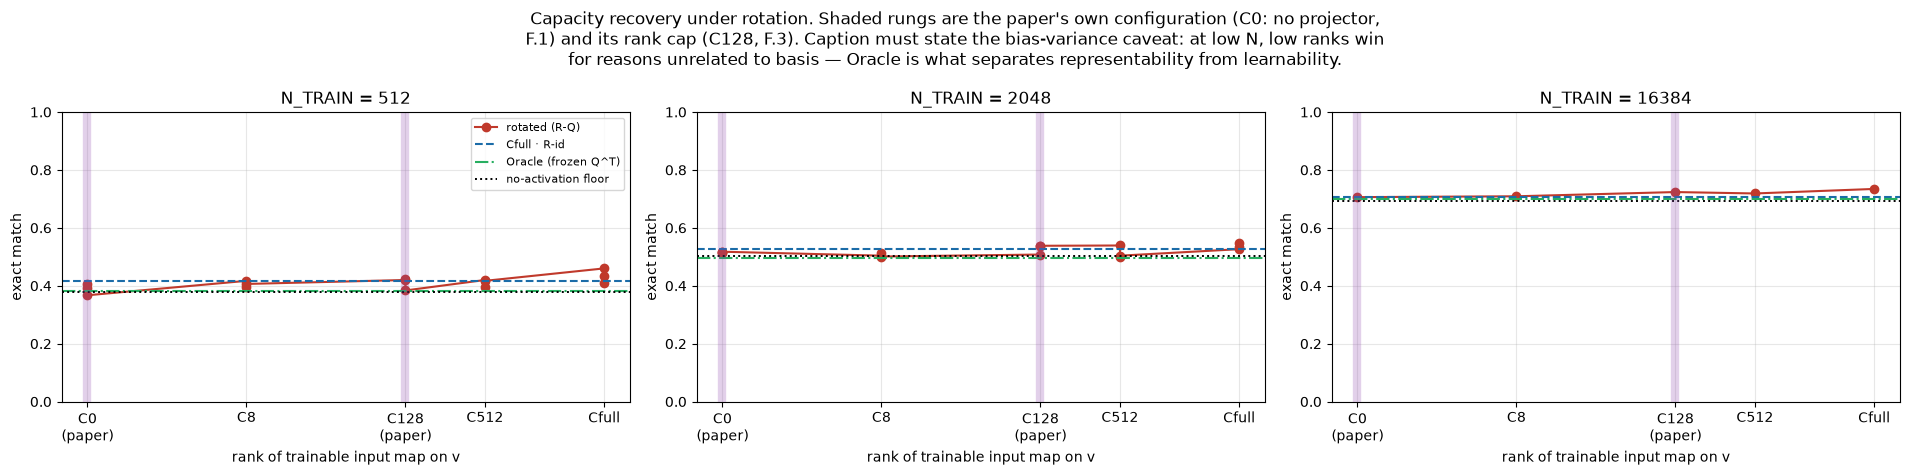

In [10]:
import matplotlib.pyplot as plt

RANK_X = {"C0": 0.5, "C8": 8, "C128": 128, "C512": 512, "Cfull": 4096}
PAPER_RUNGS = {"C0", "C128"}          # F.1: no projector at all; F.3: rank-128 cap
prereg = json.load(open(f"{C.REPORTS_DIR}/preregistration.json"))
metric = prereg["primary_metric"]

# the floor NB03 measured, which is where this axis actually starts
floor_path = f"{C.REPORTS_DIR}/no_activation_floor.csv"
floors = {}
if os.path.exists(floor_path):
    fdf = pd.read_csv(floor_path)
    floors = dict(zip(fdf.n_train.astype(int), fdf[metric]))
else:
    print("no no_activation_floor.csv — run NB03 §1 first; plotting without the floor")

fig, axes = plt.subplots(1, len(C.N_TRAIN_LADDER),
                         figsize=(6.4 * len(C.N_TRAIN_LADDER), 4.8), squeeze=False)
for ax, n in zip(axes[0], C.N_TRAIN_LADDER):
    # one point per rung, averaged over C.seeds_for(n) -- plotting the raw frame would draw
    # three overlaid points per rank and connect them in seed order
    sub = (ladder[(ladder.rotation == "Q") & (ladder.n_train == n)
                  & (ladder.capacity.isin(RANK_X))]
           .groupby("capacity")[metric].agg(["mean", "std", "count"]).reset_index())
    sub = sub.assign(x=sub.capacity.map(RANK_X)).sort_values("x")
    ax.errorbar(sub.x, sub["mean"], yerr=sub["std"].fillna(0.0), marker="o", capsize=3,
                color="#c0392b", label="rotated (R-Q), mean +/- sd over seeds")

    for cap, rot, color, style, name in [
        ("Cfull", "identity", "#1b6ca8", "--", "Cfull · R-id"),
        ("Oracle", "Q", "#27ae60", "-.", "Oracle (frozen Q^T)"),
    ]:
        ref = ladder[(ladder.rotation == rot) & (ladder.capacity == cap)
                     & (ladder.n_train == n)][metric]
        if len(ref):
            ax.axhline(ref.mean(), color=color, linestyle=style, label=name)
    if n in floors:
        ax.axhline(floors[n], color="black", linestyle=":", linewidth=1.4,
                   label="no-activation floor")

    # the paper's own rungs, called out on the axis
    for cap in PAPER_RUNGS:
        if cap in RANK_X:
            ax.axvline(RANK_X[cap], color="#8e44ad", alpha=0.25, linewidth=6)
    ax.set_xscale("log", base=2)
    ax.set_xticks(list(RANK_X.values()))
    ax.set_xticklabels([f"{k}\n(paper)" if k in PAPER_RUNGS else k for k in RANK_X])
    ax.set_xlabel("rank of trainable input map on v")
    ax.set_ylabel(metric.replace("_", " "))
    ax.set_title(f"N_TRAIN = {n}")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
axes[0][0].legend(fontsize=8)
fig.suptitle("Capacity recovery under rotation. Shaded rungs are the paper's own configuration "
             "(C0: no projector,\nF.1) and its rank cap (C128, F.3). Caption must state the "
             "bias-variance caveat: at low N, low ranks win\nfor reasons unrelated to basis — "
             "Oracle is what separates representability from learnability.")
fig.tight_layout()
fig.savefig(f"{C.FIGURES_DIR}/capacity_recovery.png", dpi=150)
plt.show()


In [11]:
frac = prereg["thresholds"]["recovery_fraction"]


def rows_for(rot, cap, n):
    return ladder[(ladder.rotation == rot) & (ladder.capacity == cap) & (ladder.n_train == n)]


def get(rot, cap, n):
    # the mean over C.seeds_for(n). This was r.iloc[0] and so reported seed 67 alone at every
    # N in MULTI_SEED_N, which is a third of the runs and flipped the N=512 threshold.
    r = rows_for(rot, cap, n)
    return float(r[metric].mean()) if len(r) else None


ladder_rows = []
for n in C.N_TRAIN_LADDER:
    ref = get("identity", "Cfull", n)
    oracle = get("Q", "Oracle", n)
    fl = floors.get(n)
    if ref is None:
        continue

    def retained(v):
        return S.fraction_retained(v, fl, ref) if (fl is not None and v is not None) else None

    print(f"N = {n}   (floor {fl if fl is None else round(fl, 3)}, "
          f"reference {ref:.3f} — the axis is {'' if fl is None else round(ref - fl, 3)} wide)")
    for cap in LADDER + ["Oracle"]:
        v = get("Q", cap, n)
        if v is None:
            continue
        r = retained(v)
        tag = "  <- the paper's configuration" if cap == "C0" else (
            "  <- the paper's rank cap" if cap == "C128" else "")
        k = len(rows_for("Q", cap, n))
        sd = rows_for("Q", cap, n)[metric].std()
        print(f"  R-Q {cap:>7}: {metric} {v:.3f}"
              + (f" +/- {sd:.3f}" if k > 1 else " (1 seed)")
              + (f"   retained {r:+.2f}" if r is not None else "") + tag)
        ladder_rows.append({"n_train": n, "capacity": cap, "raw": v, "retained": r,
                            "n_seeds": k, "sd": None if k < 2 else float(sd),
                            "floor": fl, "reference": ref})

    recovered = [cap for cap in LADDER if (retained(get("Q", cap, n)) or -9) >= frac]
    print(f"  recovery threshold   : {recovered[0] if recovered else 'none recovered'} "
          f"(>= {frac:.0%} of the activation's contribution)")
    if oracle is not None:
        cfull_q = get("Q", "Cfull", n)
        if cfull_q is not None and fl is not None:
            print(f"  learnability cost    : Oracle - Cfull/R-Q = "
                  f"{(retained(oracle) - retained(cfull_q)):+.2f} of the contribution "
                  f"({oracle - cfull_q:+.3f} raw)")
        print(f"  irreducible rotation cost: Cfull/R-id - Oracle = {ref - oracle:+.3f} raw")
    print()

if ladder_rows:
    pd.DataFrame(ladder_rows).to_csv(f"{C.REPORTS_DIR}/capacity_ladder_normalized.csv",
                                     index=False)

print("Read this against §3.5's caveat, and put it in the figure caption: at N = 512 a 4096^2 map")
print("is being fit from 512 injected vectors, so low ranks win at low N for bias-variance")
print("reasons with the basis effect sitting inside that. Oracle plus the ladder is what")
print("disentangles them — the recovery threshold alone does not.")


N = 512   (floor 0.378, reference 0.415 — the axis is 0.037 wide)
  R-Q      C0: exact_match 0.392   retained +0.36  <- the paper's configuration
  R-Q      C8: exact_match 0.406   retained +0.76
  R-Q    C128: exact_match 0.424   retained +1.24  <- the paper's rank cap
  R-Q    C512: exact_match 0.420   retained +1.13
  R-Q   Cfull: exact_match 0.460   retained +2.22
  R-Q  Oracle: exact_match 0.383   retained +0.12
  recovery threshold   : C128 (>= 90% of the activation's contribution)
  learnability cost    : Oracle - Cfull/R-Q = -2.10 of the contribution (-0.077 raw)
  irreducible rotation cost: Cfull/R-id - Oracle = +0.032 raw

N = 2048   (floor 0.503, reference 0.525 — the axis is 0.022 wide)
  R-Q      C0: exact_match 0.518   retained +0.65  <- the paper's configuration
  R-Q      C8: exact_match 0.501   retained -0.09
  R-Q    C128: exact_match 0.538   retained +1.57  <- the paper's rank cap
  R-Q    C512: exact_match 0.539   retained +1.61
  R-Q   Cfull: exact_match 0.526   re